# Ejemplos Prácticos de Kernels de Convolución

## Contenido
1. ¿Que es un Kernel?
2. Kernels Comunes y sus Efectos
   - Kernel de Identidad
   - Kernel de Desenfoque (Blur)
   - Kernel de Deteccion de Bordes
   - Kernel de Enfoque (Sharpen)
   - Kernel de Relieve (Emboss)
   - Kernel de Sobel
   - Kernel de Laplace
   - Kernel de Deteccion de Esquinas
3. Visualizacion de Kernels en Accion
4. Aplicacion a Imagenes Reales
5. Kernels Personalizados

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from skimage import data, color, exposure
from skimage.transform import resize
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

def aplicar_kernel(imagen, kernel):
    """Aplica un kernel de convolucion a una imagen"""
    if len(imagen.shape) == 3:
        imagen = color.rgb2gray(imagen)
    resultado = signal.convolve2d(imagen, kernel, mode='same', boundary='symm')
    resultado = exposure.rescale_intensity(resultado, out_range=(0, 1))
    return resultado

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


## 1. Kernel de Identidad
El kernel de identidad no modifica la imagen.

In [2]:
kernel_identidad = np.array([[0, 0, 0],
                             [0, 1, 0],
                             [0, 0, 0]])
print("Kernel de Identidad:")
print(kernel_identidad)

Kernel de Identidad:
[[0 0 0]
 [0 1 0]
 [0 0 0]]


## 2. Kernel de Desenfoque (Blur)
Suaviza la imagen promediando los pixeles vecinos.

In [3]:
kernel_blur = np.ones((3, 3)) / 9
print("Kernel de Desenfoque:")
print(kernel_blur)

Kernel de Desenfoque:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


## 3. Kernel de Deteccion de Bordes
Resalta los bordes de los objetos.

In [4]:
kernel_bordes = np.array([[-1, -1, -1],
                          [-1,  8, -1],
                          [-1, -1, -1]])
print("Kernel de Deteccion de Bordes:")
print(kernel_bordes)

Kernel de Deteccion de Bordes:
[[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]


## 4. Kernel de Enfoque (Sharpen)
Realza los detalles y bordes de la imagen.

In [5]:
kernel_enfoque = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])
print("Kernel de Enfoque:")
print(kernel_enfoque)

Kernel de Enfoque:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


## 5. Kernel de Relieve (Emboss)
Crea un efecto 3D.

In [6]:
kernel_relieve = np.array([[-2, -1, 0],
                           [-1,  1, 1],
                           [ 0,  1, 2]])
print("Kernel de Relieve:")
print(kernel_relieve)

Kernel de Relieve:
[[-2 -1  0]
 [-1  1  1]
 [ 0  1  2]]


## 6. Kernel de Sobel (Deteccion Direccional)
Detecta bordes en direcciones especificas.

In [7]:
kernel_sobel_x = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]])

kernel_sobel_y = np.array([[-1, -2, -1],
                           [ 0,  0,  0],
                           [ 1,  2,  1]])

print("Kernel Sobel X (horizontal):")
print(kernel_sobel_x)
print("\nKernel Sobel Y (vertical):")
print(kernel_sobel_y)

Kernel Sobel X (horizontal):
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]

Kernel Sobel Y (vertical):
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]


## 7. Kernel de Laplace
Detecta bordes en todas las direcciones.

In [8]:
kernel_laplace = np.array([[0,  1, 0],
                           [1, -4, 1],
                           [0,  1, 0]])

kernel_laplace_diag = np.array([[1,  1, 1],
                                [1, -8, 1],
                                [1,  1, 1]])

print("Kernel Laplace (4-vecindad):")
print(kernel_laplace)
print("\nKernel Laplace (8-vecindad):")
print(kernel_laplace_diag)

Kernel Laplace (4-vecindad):
[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]

Kernel Laplace (8-vecindad):
[[ 1  1  1]
 [ 1 -8  1]
 [ 1  1  1]]


## 8. Kernel de Deteccion de Esquinas

In [9]:
kernel_esquinas = np.array([[ 1, 0, -1],
                            [ 0, 0,  0],
                            [-1, 0,  1]])
print("Kernel de Deteccion de Esquinas:")
print(kernel_esquinas)

Kernel de Deteccion de Esquinas:
[[ 1  0 -1]
 [ 0  0  0]
 [-1  0  1]]


## Visualizacion de Kernels en Accion

Vamos a crear una imagen de prueba con formas geometricas.

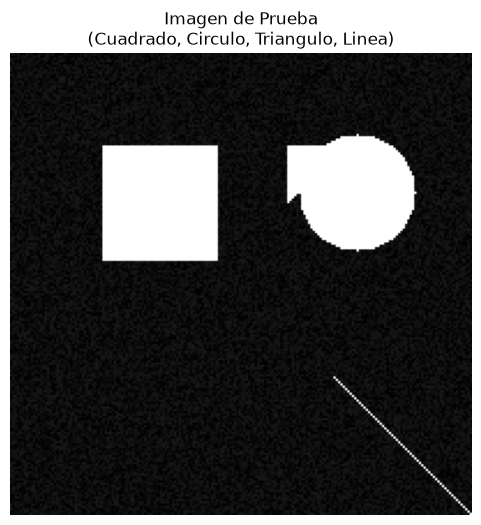

Dimensiones de la imagen: (200, 200)


In [10]:
def crear_imagen_prueba(tamano=200):
    """Crea una imagen de prueba con formas geometricas"""
    imagen = np.zeros((tamano, tamano))
    
    # Cuadrado
    imagen[40:90, 40:90] = 1.0
    
    # Circulo
    y, x = np.ogrid[:tamano, :tamano]
    circulo = (x - 150)**2 + (y - 60)**2 <= 25**2
    imagen[circulo] = 1.0
    
    # Triangulo
    for i in range(25):
        for j in range(25 - i):
            if 40 + i < tamano and 120 + j < tamano:
                imagen[40 + i, 120 + j] = 1.0
    
    # Linea diagonal (corregida - sin exceder limites)
    for i in range(60):
        if 140 + i < tamano and 140 + i < tamano:
            imagen[140 + i, 140 + i] = 1.0
    
    # Anadir ruido
    ruido = np.random.random((tamano, tamano)) * 0.1
    imagen = np.clip(imagen + ruido, 0, 1)
    
    return imagen

# Crear imagen de prueba
imagen_prueba = crear_imagen_prueba(tamano=200)

plt.figure(figsize=(6, 6))
plt.imshow(imagen_prueba, cmap='gray')
plt.title('Imagen de Prueba\n(Cuadrado, Circulo, Triangulo, Linea)')
plt.axis('off')
plt.show()

print(f"Dimensiones de la imagen: {imagen_prueba.shape}")

### Aplicar todos los kernels a la imagen de prueba

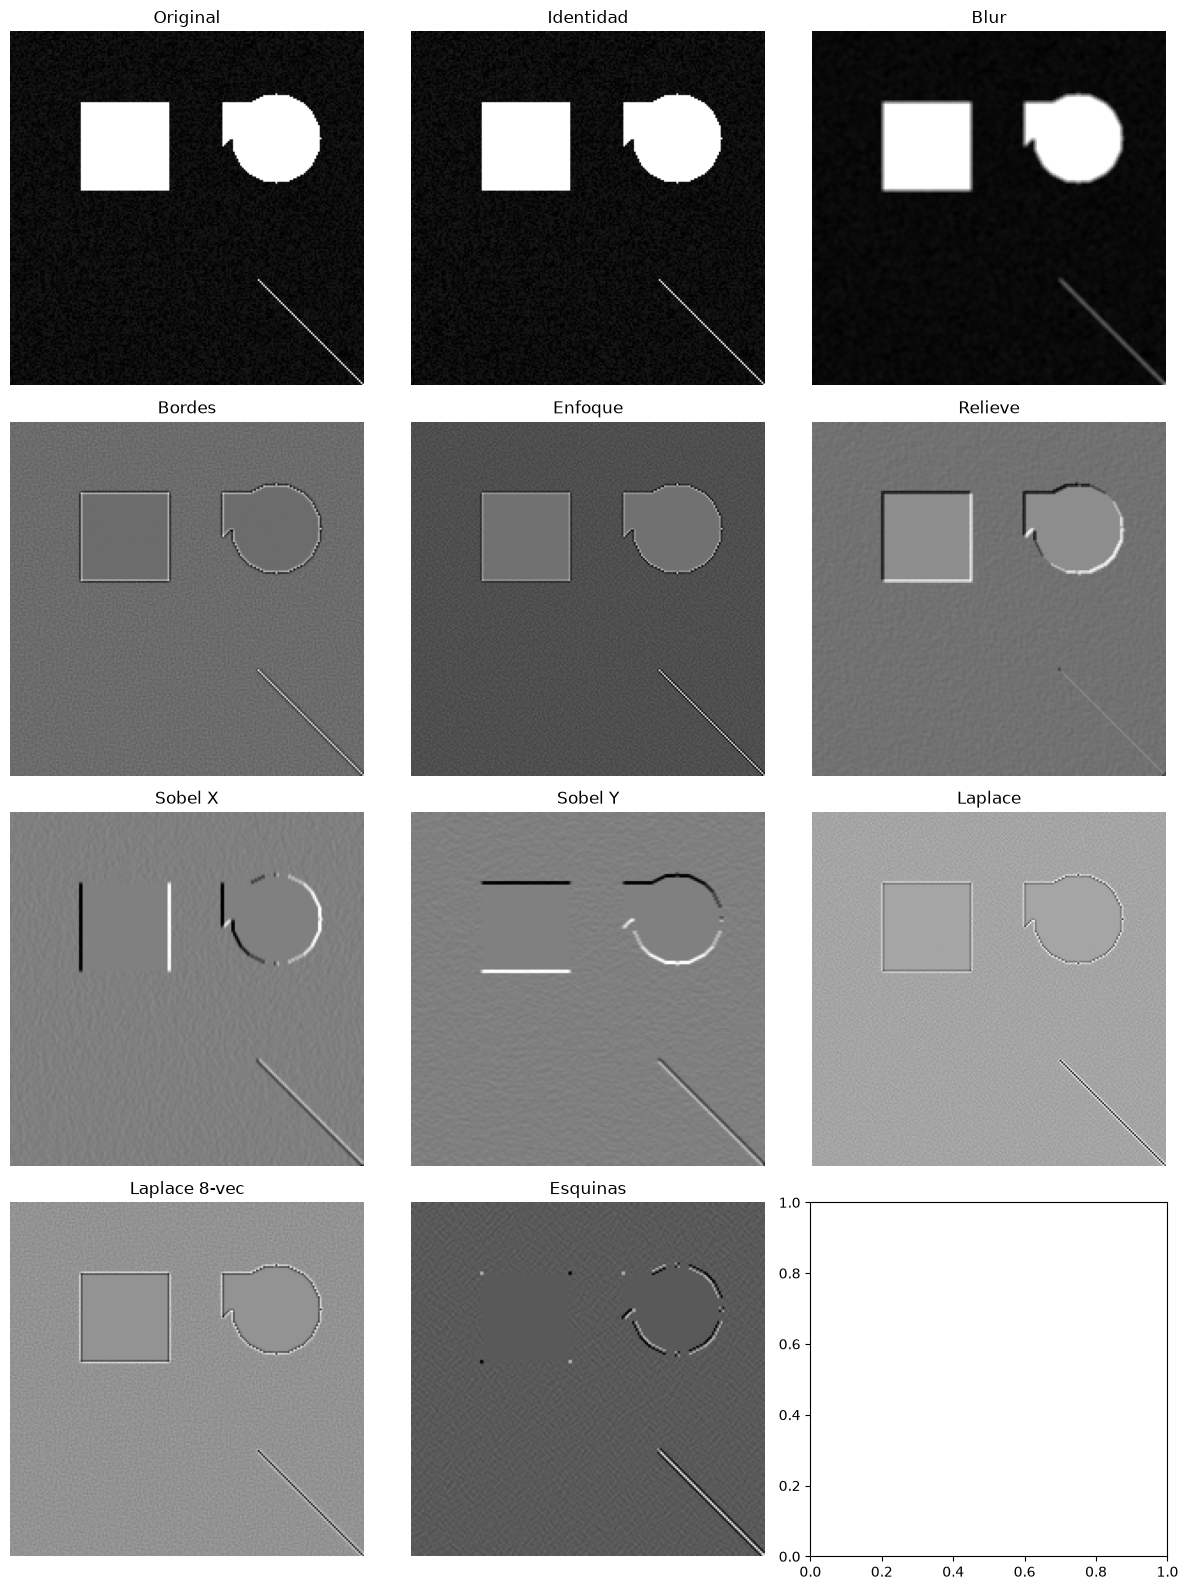

In [11]:
kernels = {
    'Identidad': kernel_identidad,
    'Blur': kernel_blur,
    'Bordes': kernel_bordes,
    'Enfoque': kernel_enfoque,
    'Relieve': kernel_relieve,
    'Sobel X': kernel_sobel_x,
    'Sobel Y': kernel_sobel_y,
    'Laplace': kernel_laplace,
    'Laplace 8-vec': kernel_laplace_diag,
    'Esquinas': kernel_esquinas
}

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
axes = axes.flatten()

# Imagen original
axes[0].imshow(imagen_prueba, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Aplicar kernels
for i, (nombre, kernel) in enumerate(kernels.items(), 1):
    resultado = aplicar_kernel(imagen_prueba, kernel)
    axes[i].imshow(resultado, cmap='gray')
    axes[i].set_title(nombre)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Aplicacion a Imagenes Reales

Ahora aplicamos los kernels a una imagen real.

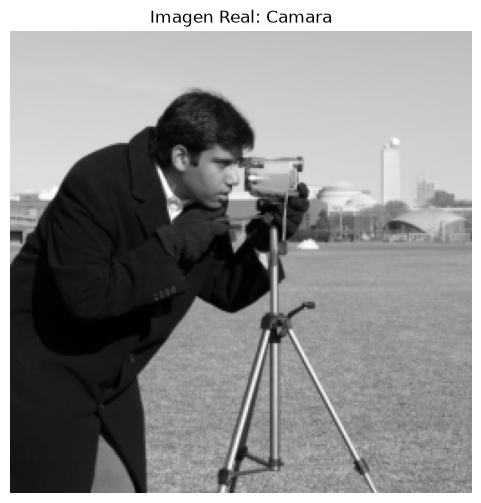

In [12]:
# Cargar una imagen real
try:
    imagen_real = data.camera()
    nombre_imagen = "Camara"
except:
    imagen_real = data.coins()
    nombre_imagen = "Monedas"

# Redimensionar
imagen_real = resize(imagen_real, (256, 256))

plt.figure(figsize=(6, 6))
plt.imshow(imagen_real, cmap='gray')
plt.title(f'Imagen Real: {nombre_imagen}')
plt.axis('off')
plt.show()

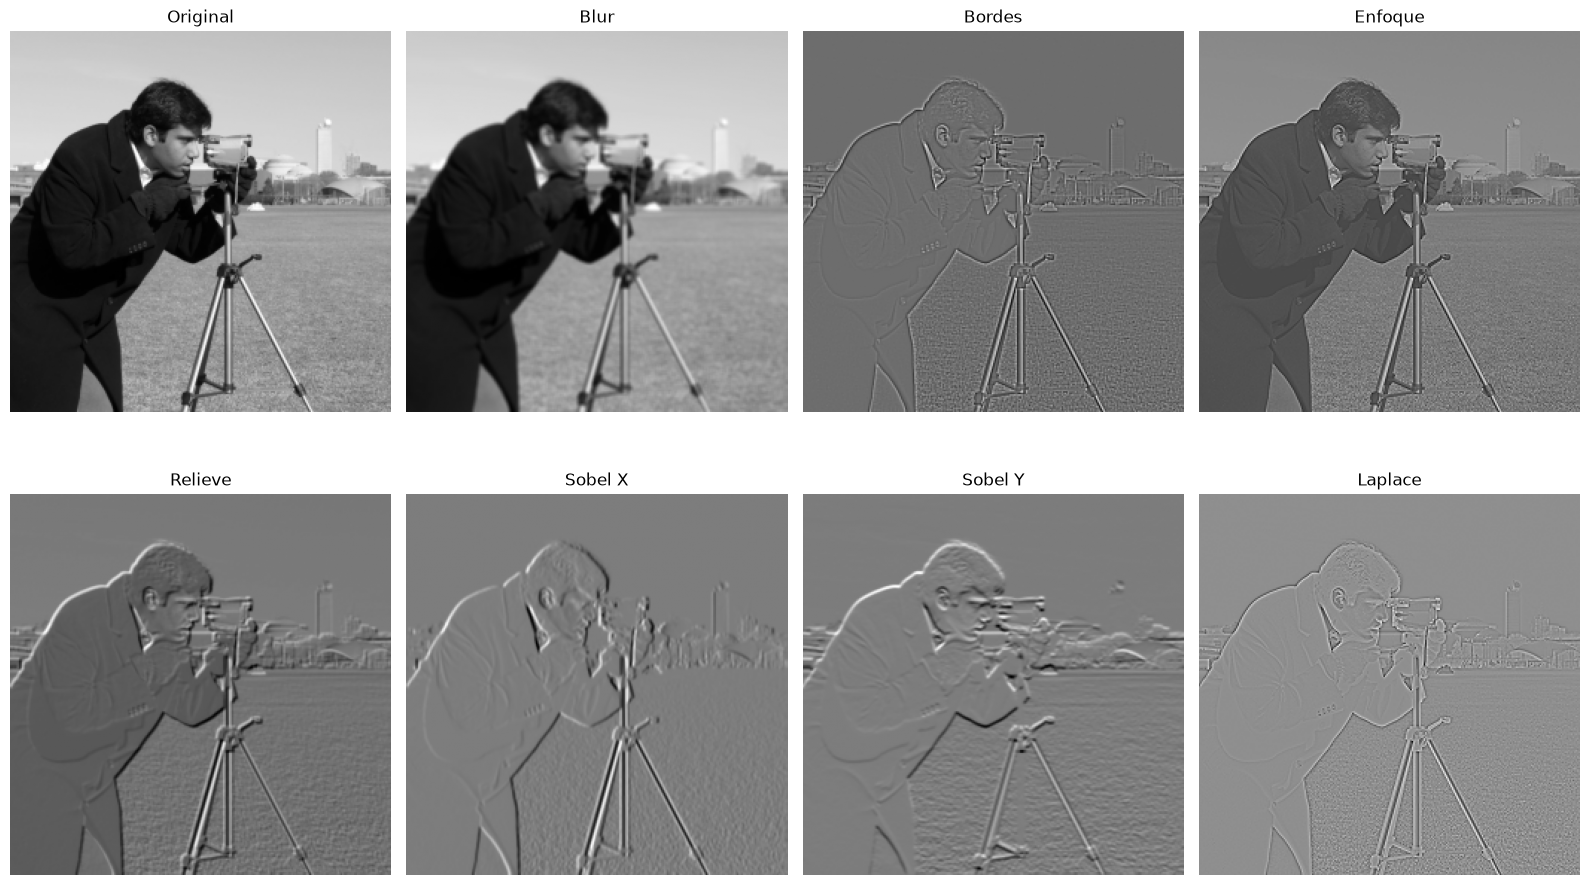

In [13]:
# Kernels mas interesantes para imagenes reales
kernels_reales = {
    'Blur': kernel_blur,
    'Bordes': kernel_bordes,
    'Enfoque': kernel_enfoque,
    'Relieve': kernel_relieve,
    'Sobel X': kernel_sobel_x,
    'Sobel Y': kernel_sobel_y,
    'Laplace': kernel_laplace
}

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

# Original
axes[0].imshow(imagen_real, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Aplicar kernels
for i, (nombre, kernel) in enumerate(kernels_reales.items(), 1):
    resultado = aplicar_kernel(imagen_real, kernel)
    axes[i].imshow(resultado, cmap='gray')
    axes[i].set_title(nombre)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Kernels Personalizados

Puedes crear tus propios kernels para efectos especificos.

In [14]:
# Kernel de lineas verticales
kernel_lineas_v = np.array([[-1,  2, -1],
                            [-1,  2, -1],
                            [-1,  2, -1]])

# Kernel de lineas horizontales
kernel_lineas_h = np.array([[-1, -1, -1],
                            [ 2,  2,  2],
                            [-1, -1, -1]])

# Kernel de diagonal
kernel_diag = np.array([[-2,  1,  0],
                        [ 1,  0, -1],
                        [ 0, -1,  2]])

# Kernel de contorno
kernel_contorno = np.array([[-1, -1, -1],
                            [-1,  8, -1],
                            [-1, -1, -1]])

# Kernel de acuarela
kernel_acuarela = np.array([[1,  1, 1],
                            [1, -4, 1],
                            [1,  1, 1]]) / 4

print("Kernels personalizados creados")

Kernels personalizados creados


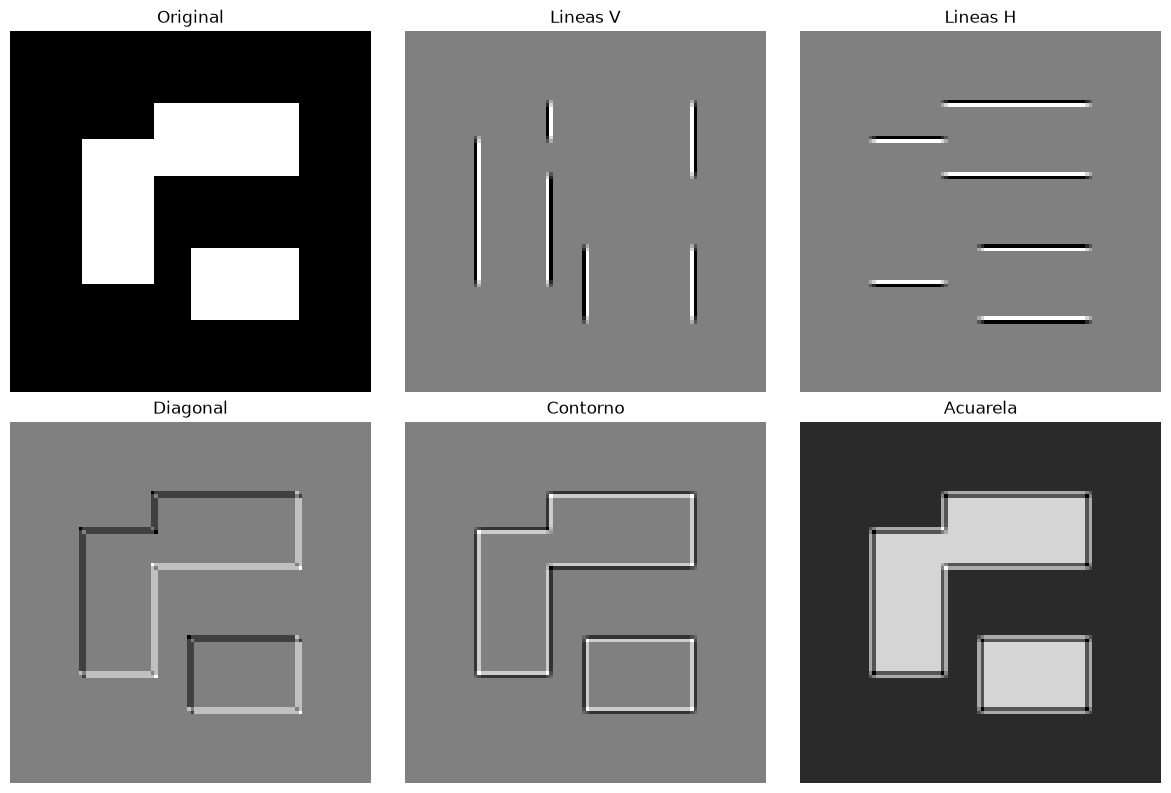

In [15]:
# Probar kernels personalizados en una imagen simple
imagen_test = np.zeros((100, 100))
imagen_test[30:70, 20:40] = 1
imagen_test[20:40, 40:80] = 1
imagen_test[60:80, 50:80] = 1

kernels_personalizados = {
    'Lineas V': kernel_lineas_v,
    'Lineas H': kernel_lineas_h,
    'Diagonal': kernel_diag,
    'Contorno': kernel_contorno,
    'Acuarela': kernel_acuarela
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

axes[0].imshow(imagen_test, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i, (nombre, kernel) in enumerate(kernels_personalizados.items(), 1):
    resultado = aplicar_kernel(imagen_test, kernel)
    axes[i].imshow(resultado, cmap='gray')
    axes[i].set_title(nombre)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Resumen de Kernels

| Kernel | Efecto | Aplicacion |
|--------|--------|------------|
| Identidad | Sin cambio | Referencia |
| Blur | Suavizado | Reduccion de ruido |
| Bordes | Resalta bordes | Segmentacion |
| Enfoque | Nitidez | Mejora de imagen |
| Relieve | Efecto 3D | Efectos artisticos |
| Sobel X | Bordes verticales | Deteccion direccional |
| Sobel Y | Bordes horizontales | Deteccion direccional |
| Laplace | Bordes multidireccional | Deteccion general |
| Esquinas | Intersecciones | Reconocimiento |

## Ejercicios Propuestos

1. **Crea un kernel** que detecte bordes en direccion de 45 grados
2. **Combina kernels** aplicando primero blur y luego bordes
3. **Experimenta** con kernels de 5x5 en lugar de 3x3
4. **Prueba** diferentes valores en el kernel de enfoque

## Consejos Practicos

1. Kernels mas grandes (5x5, 7x7) producen efectos mas pronunciados
2. La suma de pesos del kernel determina el brillo
3. Kernels simetricos producen efectos uniformes
4. Experimenta con diferentes valores para efectos unicos